#HW 4 - Morphology, Edge Detection and Contour Detection (10 pts)
---
For homework assignment HW 4, you will explore morphology, edge detection and contour detection. You can use any advanced functions. However, if you are selected for a random check, you must be able to explain your code.

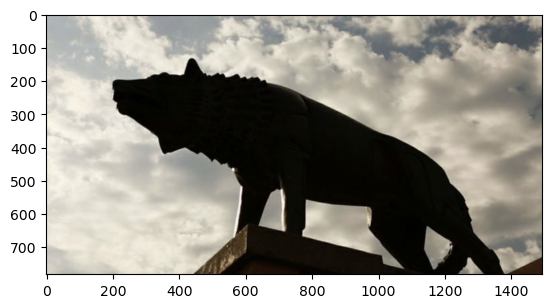

In [1]:
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt

# cv2_imshow is Colab-only (using matplotlib for display)
# from google.colab.patches import cv2_imshow
# TODO: Test notebook on Colab in case that's what the professor uses.

img_bgr = cv2.imread("Lobo.png")
if img_bgr is None:
	sys.exit("Could not load 'Lobo.png'.")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

###Task 1 (3 pts)

Canny edge detection:

1. Smoothing Filter Selection: Canny edge detection is sensitive to noise.You must select the **two best** smoothing filters from our lectures to process Lobo.png image and display the filtered results.

2. Apply Canny edge detection to the filtered images, adjust the thresholds for each to get the cleanest possible boundary of the subject. Display the best result from your experiments.

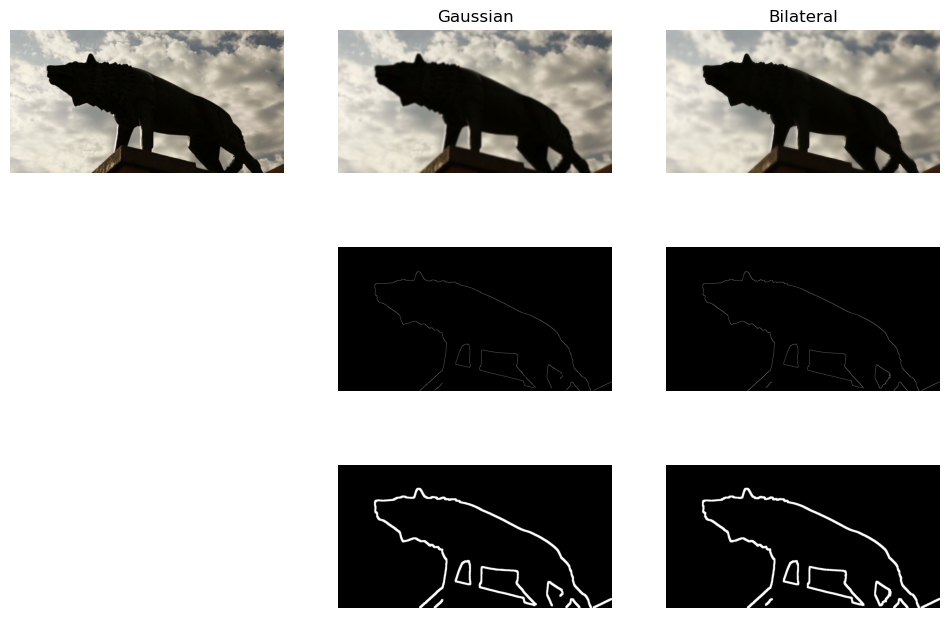

In [2]:
# 1. Pre-smooth before Canny

sigma = 3.65
gaussian_blur = cv2.GaussianBlur(img, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)

d, sigmaColor, sigmaSpace = 25, 225, 75
bilateral_blur = cv2.bilateralFilter(img, d, sigmaColor, sigmaSpace)

# 2. Canny edge detection

edges_gauss = cv2.Canny(gaussian_blur, threshold1=50, threshold2=150)
edges_bilat = cv2.Canny(bilateral_blur, threshold1=100, threshold2=200)

# 3. Dilate as edge enhancement (optional)

rect_10x10 = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 10))
dilated_gauss = cv2.dilate(edges_gauss, rect_10x10)
dilated_bilat = cv2.dilate(edges_bilat, rect_10x10)

# 4. Visualize

_, axs = plt.subplots(3, 3, figsize=(12, 8))
axs[0, 0].imshow(img)

axs[0, 1].set_title("Gaussian")
axs[0, 1].imshow(gaussian_blur)
axs[1, 1].imshow(edges_gauss, cmap='gray')
axs[1, 2].imshow(edges_bilat, cmap='gray')

axs[0, 2].set_title("Bilateral")
axs[0, 2].imshow(bilateral_blur)
axs[2, 1].imshow(dilated_gauss, cmap='gray')
axs[2, 2].imshow(dilated_bilat, cmap='gray')

for ax in axs.ravel():
    ax.axis('off')

plt.show()

###Task 2 (7 pts)

Develop a pipeline to separate the UNM Lobo statue from the high-contrast sky and clouds environment:

1. Color pre-processing: evaluate the original image in grayscale and across individual RGB channels. Select and display the single channel (or grayscale version) that provides the maximum contrast between the Lobo statue and the background.

2. Image smoothing: apply the best filter identified in Task 1 (e.g., Box, Median, Gaussian or Bilateral Gaussian, etc.) to the image from step 1. The goal is to suppress cloud noise while preserving the statue's edges.

3. Segmentation: convert the smoothed image into a binary mask using appropriate thresholds.

4. Morphology: apply opening and closing operations to clean the mask.

5. Boundary Detection & Visualization



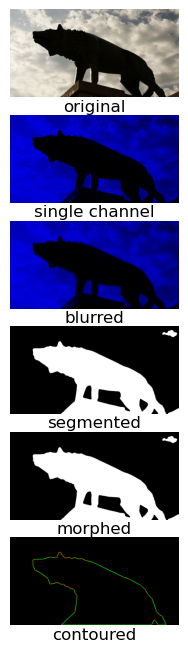

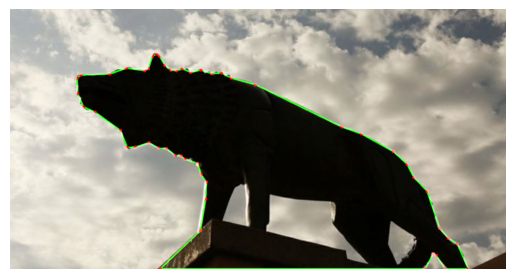

In [ ]:
# 1. Color pre-processing

# The blue channel works best for segmentation here because the sky is predominantly blue, 
# making it easier to distinguish the statue from the sky and clouds.

# The blue channel produces a mask with fewer cloud fragments
img_blues = np.zeros_like(img)
img_blues[..., 2] = img[..., 2]

# 2. Image smoothing

# Bilateral works best for smoothing here because it helps to blend the clouds and sky 
# (which are similar in color/intensity)

d, sigmaColor, sigmaSpace = 25, 225, 75     # d is the kernel diameter 
img_blurred = cv2.bilateralFilter(img_blues, d, sigmaColor, sigmaSpace)

# 3. Segmentation + Thresholding

otsu_threshold, img_segmented = cv2.threshold(
    cv2.cvtColor(img_blurred, cv2.COLOR_RGB2GRAY),
    0, 
    255, 
    # Invert the binary colors: we want the sky to be black and the wolf to be white
    type=cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Morphology

ellipse_9x9 = cv2.getStructuringElement(shape=cv2.MORPH_ELLIPSE, ksize=(9, 9))
opening = cv2.morphologyEx(img_segmented, op=cv2.MORPH_OPEN, kernel=ellipse_9x9)
closing = cv2.morphologyEx(opening, op=cv2.MORPH_CLOSE, kernel=ellipse_9x9)
img_morphed = closing.copy()

# 5.1 Boundary Detection

contours, _ = cv2.findContours(img_morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get the largest contour only
largest_contour = max(contours, key=cv2.contourArea)

# Reduce complexity with contour approximation

# 0.001 is very fine; change to 0.01 for fewer points in the contour
# 0.001 means that tolerate deviate by 0.1% of the total length.
epsilon = 0.001 * cv2.arcLength(largest_contour, True)  # very fine

# Vertices that define the contour
approx_points = cv2.approxPolyDP(largest_contour, epsilon, True)
 
img_contoured = np.zeros_like(img)    # empty buffer

cv2.drawContours(img_contoured, [approx_points], -1, (0, 255, 0), 4)  # green lines

# Draw contour points
for pt in approx_points:
    cv2.circle(img_contoured, center=(tuple(pt[0])), radius=5, color=(255, 0, 0), thickness=-1) # red circles

# Result has original image + contour lines and points
res = img * (img_contoured == 0) + img_contoured    # mask out contour buffer from image, then add it to result 

# 5.2 Visualization

_, axs = plt.subplots(6, 1, figsize=(12, 8))

axs[0].imshow(img) 
axs[0].set_title("original")
axs[1].imshow(img_blues, cmap='gray')
axs[1].set_title("single channel")
axs[2].imshow(img_blurred, cmap='gray')
axs[2].set_title("blurred")
axs[3].imshow(img_segmented, cmap='gray')
axs[3].set_title(f"segmented")
axs[4].imshow(img_morphed, cmap='gray') 
axs[4].set_title(f"morphed")
axs[5].imshow(img_contoured)
axs[5].set_title("contoured")

for ax in axs.ravel():
    ax.axis('off')
    ax.set_title(ax.get_title(), y=-0.25)
    

plt.show()

plt.imshow(res)
plt.axis('off')
plt.show()


6. Extract the Silhouette (choose only one from the following):

* Generate a solid binary mask of the target object. Using your detected
contour, fill the interior region with white pixels on a black background to create a solid silhouette.

* Alternatively, you may use morphological operations to refine the region, provided the resulting shape accurately represents the Lobo statue.

(it is fine if your result is slightly different with the displayed image below. And feel free to come up with your approach to do the work)

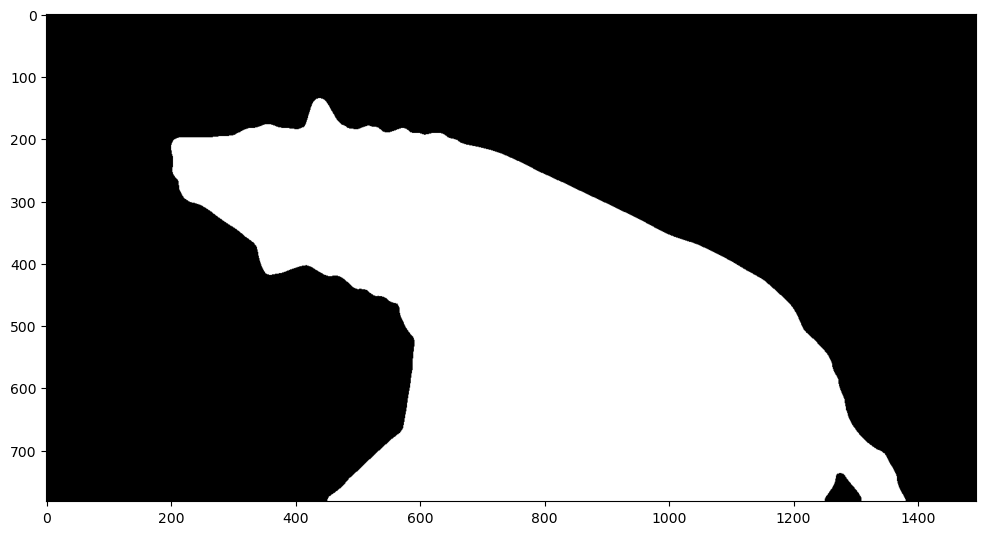

In [4]:
# Use cv2.drawContours to turn the contour into a solid silhouette

silhouette = np.zeros_like(img_morphed)

# thickness = -1 fills the contour
cv2.drawContours(silhouette, contours=[largest_contour], contourIdx=-1, color=255, thickness=-1)

plt.figure(figsize=(12, 8))
plt.imshow(silhouette, cmap='gray')
plt.show()

7. Get the boundary with morphological gradient

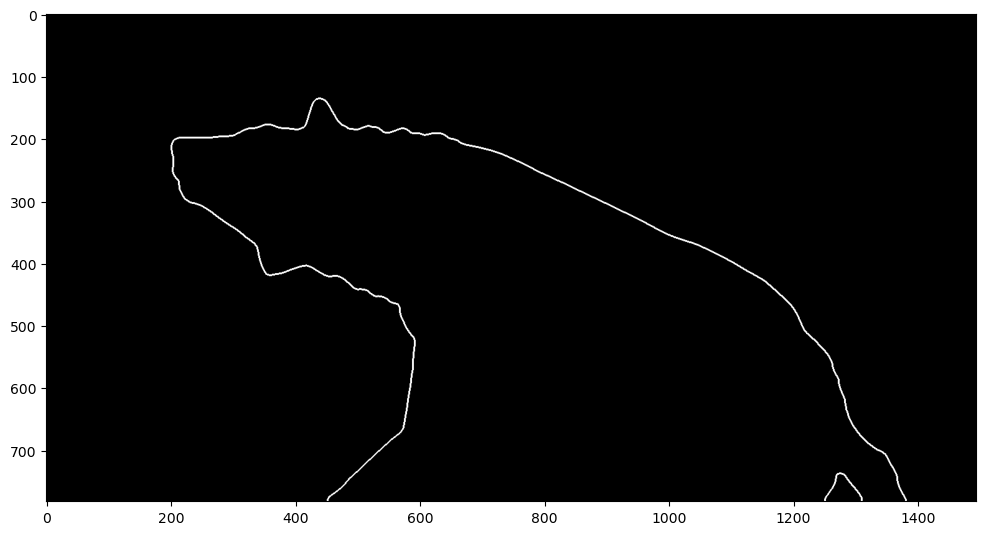

In [5]:
cross_4x4 = cv2.getStructuringElement(cv2.MORPH_CROSS, ksize=(4, 4))

# Morphological gradient = (I ⊕ K) - (I ⊖ K)
boundary = cv2.dilate(silhouette, cross_4x4) - cv2.erode(silhouette, cross_4x4)     

plt.figure(figsize=(12, 8))
plt.imshow(boundary, cmap='gray')
plt.show()